# Central Limit Theorem (CLT)
    The Central Limit Theorem (CLT) is one of the most important theorems in statistics.
    
    It states that when we repeatedly draw random samples of the same size from a population, the distribution of the sample means approaches a Normal Distribution as the sample size becomes sufficiently large.

    This happens regardless of whether the original population follows a Normal Distribution or not.
## Definition
    The Central Limit Theorem states that 
    
    "When random samples of size n are repeatedly selected from any population, the distribution of the sample means approaches a Normal Distribution as n becomes sufficiently large."

    The center of the Sampling Distribution is equal to the Population Mean.

    The spread of the Sampling Distribution is measured by the Standard Error.

                                                    Central Limit Theorem
$$
\bar{\bar{x}} \approx \mu
$$

                                                    The Standard Error is

$$
SE=\frac{\sigma}{\sqrt{n}}
$$
                                                                

### Conditions for the Central Limit Theorem
    
    1. Samples should be selected randomly.
    2. Samples should be independent.
    3. The sample size should be sufficiently large.

    A commonly Used Sample Size
$$
n \ge 30
$$

    Although this is not a strict rule, a sample size of 30 or more usually produces a Sampling Distribution that is close to Normal.

In [1]:
import numpy as np 
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
np.random.seed(42)

Customers = pd.DataFrame({
                        "Customer_ID":range(1,10001),

                        "Purchase_Amount":np.random.exponential(scale=3000,size=10000)

                })

Customers.head()

,Customer_ID,Purchase_Amount
0,1,1407.804270
1,2,9030.364293
2,3,3950.237081
3,4,2738.827661
4,5,508.874611


In [4]:
Customers.describe().round(2)

,Customer_ID,Purchase_Amount
count,10000.00,10000.00
mean,5000.50,2932.50
std,2886.90,2923.21
min,1.00,0.03
25%,2500.75,848.40
50%,5000.50,2034.94
75%,7500.25,4041.29
max,10000.00,24517.34


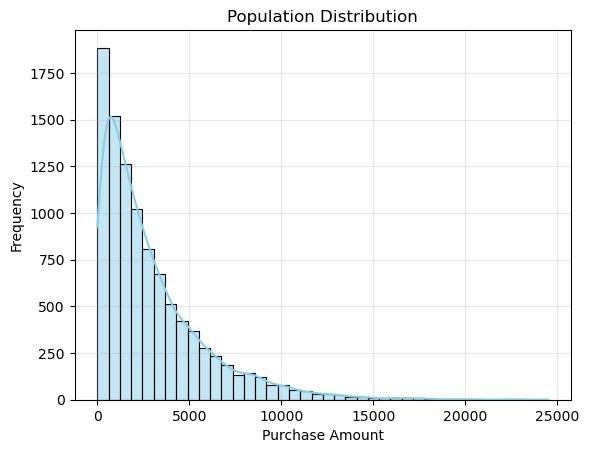

In [5]:
sns.histplot(
    Customers["Purchase_Amount"],
    bins=40,
    kde=True,
    color="skyblue"
)

plt.title("Population Distribution")

plt.xlabel("Purchase Amount")

plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

### WE Obesrve That
    Notice that the population distribution is highly right-skewed.

    Most customers spend relatively small amounts.

    Only a few customers make very large purchases.

    This population is clearly not normally distributed.


In [6]:
population_mean = Customers["Purchase_Amount"].mean()

population_std = Customers["Purchase_Amount"].std(ddof=0)

print(f"Population Mean : {population_mean:.2f}")

print(f"Population Standard Deviation : {population_std:.2f}")

Population Mean : 2932.50
Population Standard Deviation : 2923.07


In [12]:
sample = Customers.sample( n=300, random_state=42 )

sample.head()

,Customer_ID,Purchase_Amount
6252,6253,1235.100221
4684,4685,4481.709496
1731,1732,2933.667428
4742,4743,108.717009
4521,4522,2581.979786


In [13]:
sample["Purchase_Amount"].mean()

np.float64(3118.4363683025704)

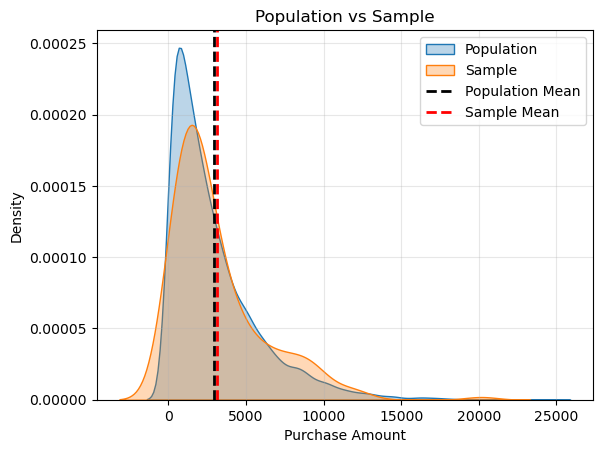

In [11]:
sns.kdeplot(
    Customers["Purchase_Amount"],
    fill=True,
    alpha=0.3,
    label="Population"
)

sns.kdeplot(  
        sample["Purchase_Amount"],
        fill=True,
        alpha=0.3,
        label="Sample"
)

plt.axvline(Customers["Purchase_Amount"].mean(),color="black",linestyle="--",linewidth=2,label="Population Mean")

plt.axvline(sample["Purchase_Amount"].mean(),color="red",linestyle="--",linewidth=2,label="Sample Mean")

plt.title("Population vs Sample")

plt.xlabel("Purchase Amount")

plt.ylabel("Density")

plt.legend()

plt.grid(alpha=0.3)

plt.show()


### Simulating the Central Limit Theorem

    The best way to understand the Central Limit Theorem is through simulation.

    Instead of taking only one sample, we repeatedly select many random samples of the same size.

    For every sample, we calculate the sample mean.

    Finally, we visualize the distribution of all sample means.

In [8]:
sample_size = 30
num_samples = 1000
sample_means = []

In [9]:
for i in range(num_samples):
    sample = Customers.sample( n=sample_size,replace=False )
    
    sample_means.append(  sample["Purchase_Amount"].mean()  )

In [10]:
sample_means = pd.DataFrame({  "Sample Mean":sample_means })

sample_means.head()

,Sample Mean
0,2955.187835
1,3184.906161
2,2453.967468
3,2233.087981
4,3287.776135


In [11]:
sample_means.describe().round(2)

,Sample Mean
count,1000.00
mean,2938.17
std,537.80
min,1493.13
25%,2545.32
50%,2914.00
75%,3281.91
max,4747.66


### Mean of Sample Means
    According to the Central Limit Theorem,

    the average of the sample means should be approximately equal to the population mean.

In [12]:
population_mean = Customers["Purchase_Amount"].mean()

mean_of_sample_means = sample_means["Sample Mean"].mean()

print(f"Population Mean      : {population_mean:.2f}")

print(f"Mean of Sample Means : {mean_of_sample_means:.2f}")

Population Mean      : 2932.50
Mean of Sample Means : 2938.17


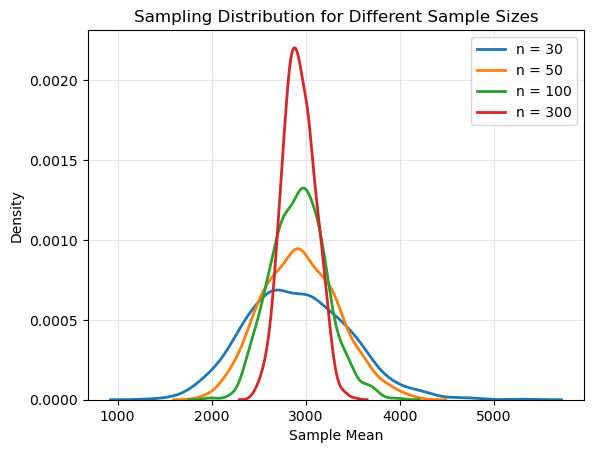

In [26]:
sample_sizes=[30,50,100,300]

for n in sample_sizes:
    means = []

    for i in range(1000):
        sample = Customers.sample(n=n)
        means.append(sample["Purchase_Amount"].mean())
        
    sns.kdeplot(
        means,
        linewidth=2,
        label=f"n = {n}"
    )

plt.title("Sampling Distribution for Different Sample Sizes")

plt.xlabel("Sample Mean")

plt.ylabel("Density")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

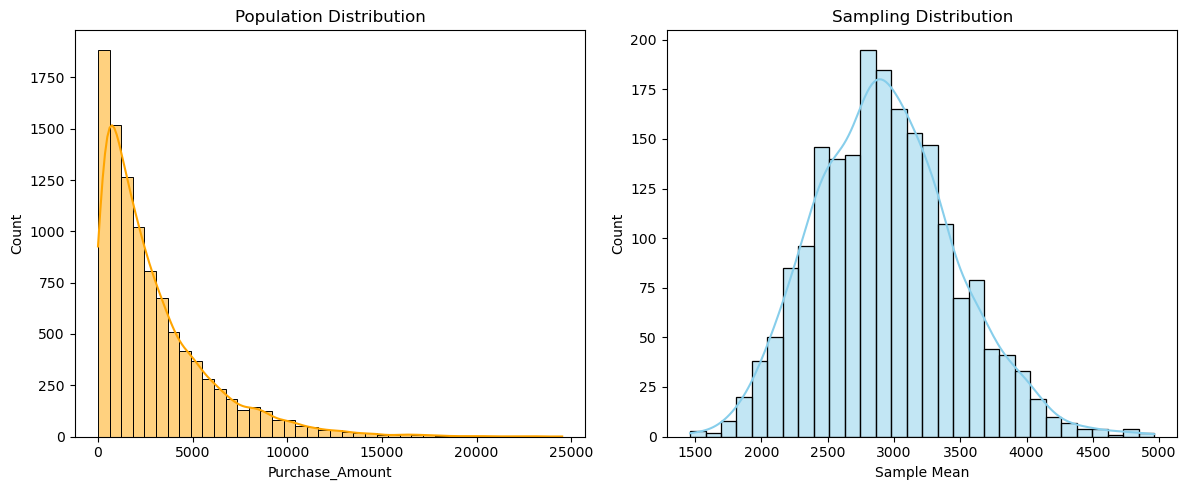

In [24]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

sns.histplot(
    Customers["Purchase_Amount"],
    bins=40,
    kde=True,
    color="orange"
)

plt.title("Population Distribution")

plt.subplot(1,2,2)

sns.histplot(
    sample_means["Sample Mean"],
    bins=30,
    kde=True,
    color="skyblue"
)

plt.title("Sampling Distribution")

plt.tight_layout()

plt.show()

### We Can Observe
    The Population Distribution is heavily right-skewed.

    The Sampling Distribution is approximately Normal.

    This transformation is the most important result of the Central Limit Theorem.

### Why is n ≥ 30 Commonly Used?
    A sample size of 30 is often used as a practical guideline because it is usually large enough for the Sampling Distribution of the Mean to become approximately Normal.

    This is not a strict mathematical rule.
        If the population itself is normally distributed, even small sample sizes may be sufficient.

    If the population is highly skewed, a larger sample size such as 50 or 100 may be required.

In [5]:
population_std = Customers["Purchase_Amount"].std(ddof=0)

sample_sizes = [5,10,20,30,50,100,200]

SE = []

for n in sample_sizes:
    SE.append(   population_std / np.sqrt(n)    )

SE_df = pd.DataFrame({

                        "Sample Size":sample_sizes,

                        "Standard Error":SE

})

SE_df.round(2)

,Sample Size,Standard Error
0,5,1307.24
1,10,924.36
2,20,653.62
3,30,533.68
4,50,413.38
5,100,292.31
6,200,206.69


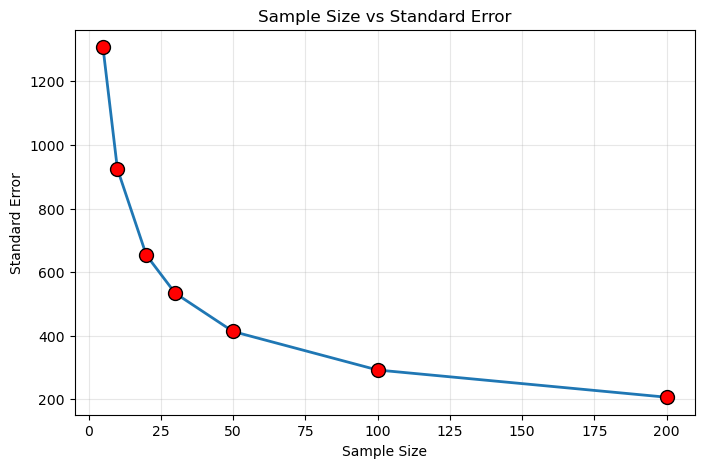

In [6]:
plt.figure(figsize=(8,5))

plt.plot(
    SE_df["Sample Size"],
    SE_df["Standard Error"],
    marker="o",
    ms=10,
    mfc='r',
    mec='black',
    linewidth=2

)

plt.title("Sample Size vs Standard Error")

plt.xlabel("Sample Size")

plt.ylabel("Standard Error")

plt.grid(alpha=0.3)

plt.show()

### Finding A Range 
    That Probability Of Population Mean Can Be Occurs Between The Range

    95% Chances Are There To Pop Mean Will Ocuur Within The Range

In [16]:
sm=sample_means["Sample Mean"]

sm.mean()

np.float64(2938.1662922367605)

In [18]:
sm.std()/np.sqrt(300)

np.float64(31.049746078604688)

In [19]:

lower_limit = sm.mean() - 2 * sm.std()/np.sqrt(300)

Upper_limit = sm.mean() + 2 * sm.std()/np.sqrt(300)

In [22]:
print('Lower_limit:',lower_limit)

Lower_limit: 2876.0668000795513


In [21]:
print ('Upper_limit:',Upper_limit)

Upper_limit: 3000.2657843939696


In [23]:
print("The Range Is :",lower_limit,"To",Upper_limit)

The Range Is : 2876.0668000795513 To 3000.2657843939696


### Population Mean

In [25]:
pop=Customers["Purchase_Amount"].mean()

In [27]:
print('Popolation Mean:',pop)

Popolation Mean: 2932.4968640707043
